In [ ]:
import os
import mne
import numpy as np
%matplotlib qt




# -------------------------
# 1) Load
# -------------------------
# Set base path
base_path = "/Users/eunice/GaTech Dropbox/Yoonsang Lee/2026/Comp Neuro/EEG/raw"


Reading EGI MFF Header from /Users/eunice/GaTech Dropbox/Yoonsang Lee/2026/Comp Neuro/EEG/raw/19193_20250508_121920.mff...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...


Reading EGI MFF Header from /Users/eunice/GaTech Dropbox/Yoonsang Lee/2026/Comp Neuro/EEG/raw/19102_20250312_091809.mff...
    Reading events ...
    Assembling measurement info ...
    Synthesizing trigger channel "STI 014" ...
    Excluding events {SESS} ...
Effective window size : 2.048 (s)


/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/2112065383.py:49: UserWarning: Zero value in spectrum for channel VREF
  raw_ec.compute_psd(fmax=60).plot()
/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/2112065383.py:49: UserWarning: Infinite value in PSD for channel VREF.
These channels might be dead.
  raw_ec.compute_psd(fmax=60).plot()


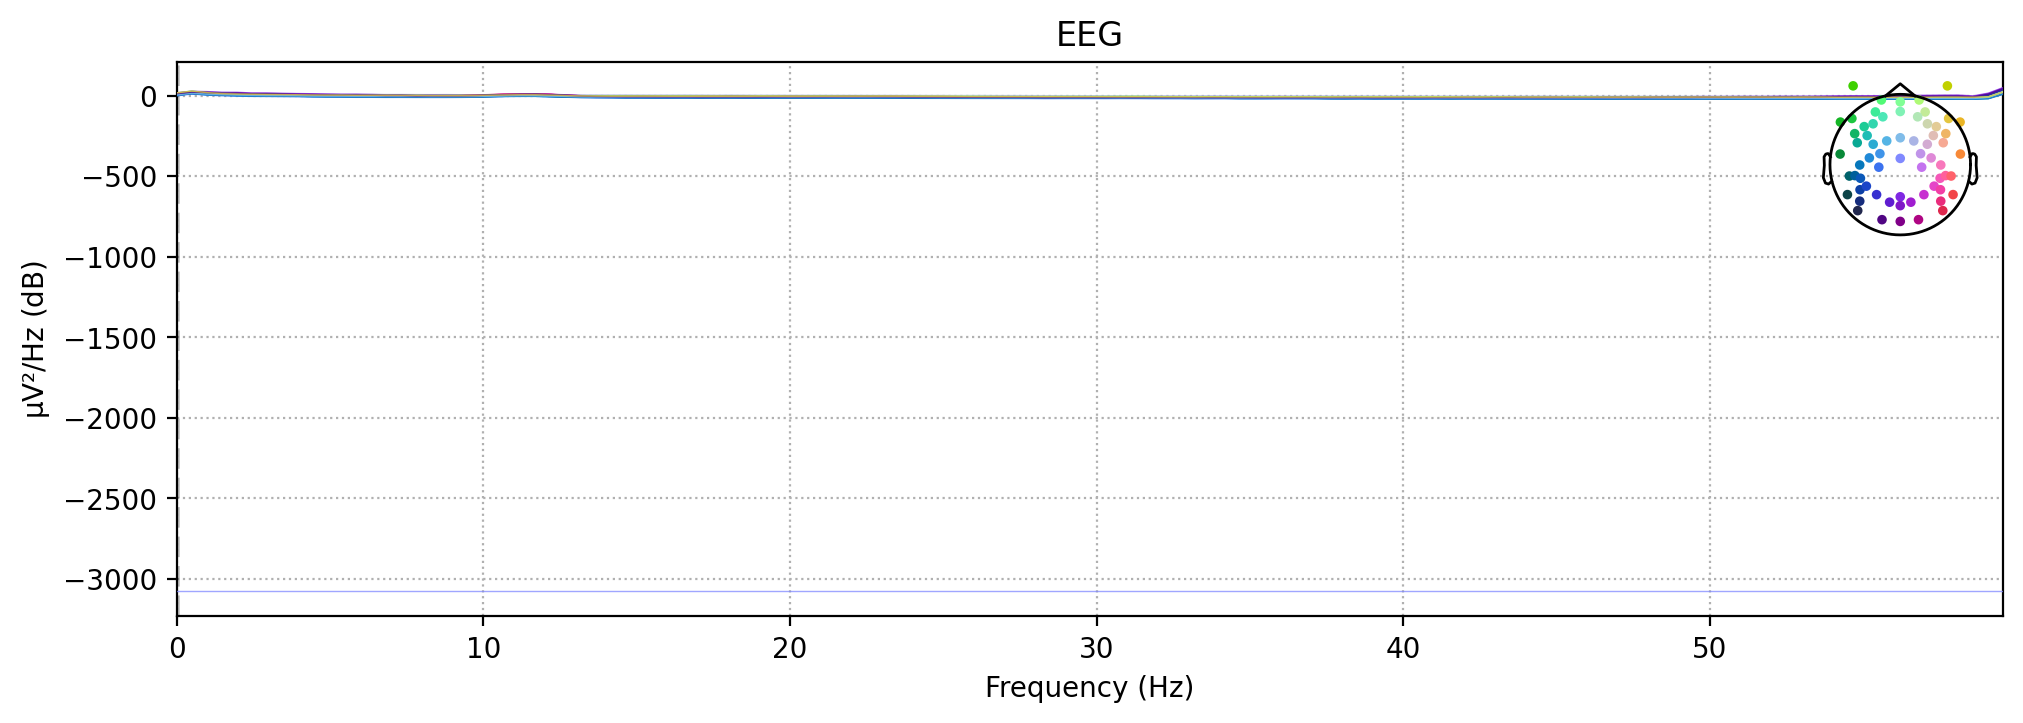

In [16]:
def crop_ec_segment(raw, discard_sec=10):
    # Find BAD_ACQ_SKIP segments
    bad_skips = [
        (onset, onset + duration)
        for onset, duration, desc in zip(
            raw.annotations.onset,
            raw.annotations.duration,
            raw.annotations.description
        )
        if desc == "BAD_ACQ_SKIP"
    ]
    if len(bad_skips) < 2:
        raise ValueError("Not enough BAD_ACQ_SKIP markers to define EC segment.")

    # Use the second segment as EC and discard the first N seconds
    ec_start = bad_skips[1][1] + discard_sec
    raw_ec = raw.copy().crop(tmin=ec_start)

    return raw_ec


def bandpower_from_epochs(epochs, bands):
    # Compute PSD on epochs (more robust than single PSD on continuous raw)
    psd = epochs.compute_psd(fmin=1, fmax=40, method="welch")
    freqs = psd.freqs
    data = psd.get_data()  # shape: (n_epochs, n_channels, n_freqs)

    feats = {}
    for band_name, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        # Mean power across epochs, channels, and freqs
        feats[f"{band_name}_power_global"] = data[:, :, idx].mean()
        # Channel-wise power (mean across epochs & freqs)
        feats[f"{band_name}_power_by_channel"] = data[:, :, idx].mean(axis=(0, 2))
    return feats



fname = "19102_20250312_091809.mff"
file_path = os.path.join(base_path, fname)
raw = mne.io.read_raw_egi(file_path, preload=False)


# -------------------------
# 2) Crop EC only
# -------------------------
raw_ec = crop_ec_segment(raw, discard_sec=10)
raw_ec.plot(n_channels=64, duration=20)
raw_ec.compute_psd(fmax=60).plot()


Reading 0 ... 590745  =      0.000 ...   590.745 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 2.048 (s)


/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/4195039420.py:4: UserWarning: Zero value in spectrum for channel VREF
  raw_tmp.compute_psd(fmax=60).plot()
/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/4195039420.py:4: UserWarning: Infinite value in PSD for channel VREF.
These channels might be dead.
  raw_tmp.compute_psd(fmax=60).plot()


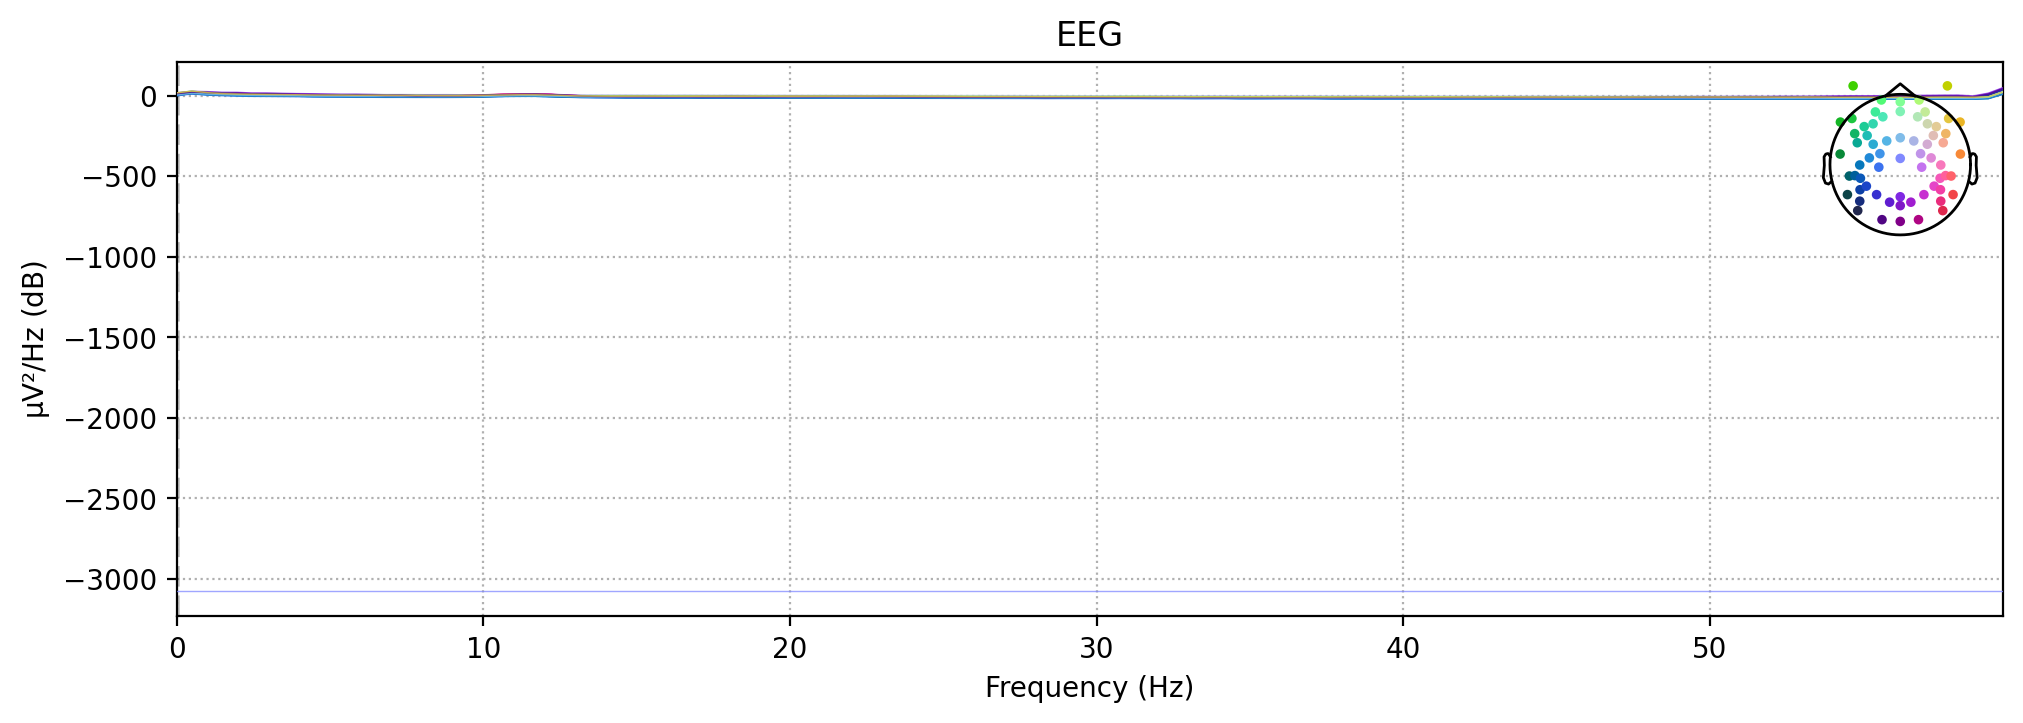

In [14]:
raw_tmp = raw_ec.copy().load_data()
raw_tmp.pick_types(eeg=True)

raw_tmp.compute_psd(fmax=60).plot()

In [15]:
import numpy as np

raw_tmp = raw_ec.copy().load_data()
raw_tmp.pick_types(eeg=True)

data = raw_tmp.get_data()
var = data.var(axis=1)

# variance가 거의 0인 채널 찾기
flat_idx = np.where(var < np.percentile(var, 1))[0]  # 아주 보수적으로 1%
flat_chs = [raw_tmp.ch_names[i] for i in flat_idx]

print("Possible flat channels:", flat_chs)
print("Min/median/max var:", var.min(), np.median(var), var.max())

Reading 0 ... 590745  =      0.000 ...   590.745 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Possible flat channels: ['VREF']
Min/median/max var: 0.0 1.3528927121922538e-07 1.0022531475384017e-05


Effective window size : 2.048 (s)


/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/3825226519.py:1: UserWarning: Zero value in spectrum for channel VREF
  psd = raw_tmp.compute_psd(fmax=60)
/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/3825226519.py:2: UserWarning: Infinite value in PSD for channel VREF.
These channels might be dead.
  psd.plot(average=True)


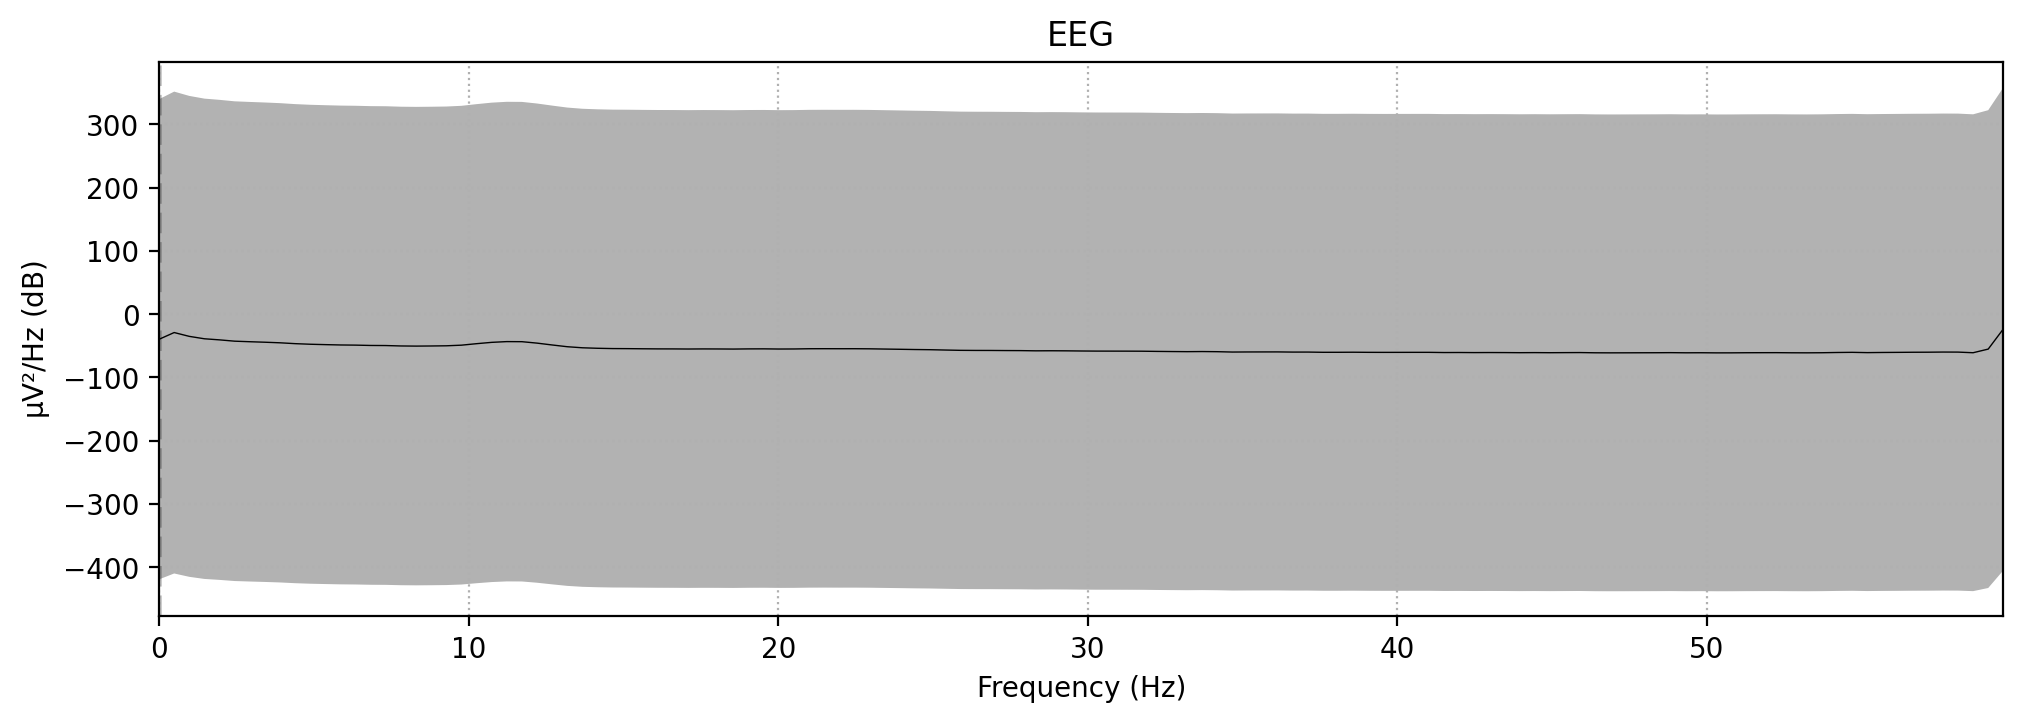

Channels marked as bad:
['E10']


In [17]:
psd = raw_tmp.compute_psd(fmax=60)
psd.plot(average=True)   

In [7]:
data = raw_ec.get_data()
print("Max:", data.max())
print("Min:", data.min())
print("Std:", data.std())



print(raw_ec)


raw_ec.plot(picks=[0], duration=10)

Max: 0.0072791440294834135
Min: -0.03291950075437203
Std: 0.006391796681962629
<RawMff | signal1.bin, 68 x 590719 (590.7 s), ~97 kB, data not loaded>


TypeError: plot() got an unexpected keyword argument 'picks'

Reading 0 ... 590718  =      0.000 ...   590.718 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 8.192 (s)


/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/1208133507.py:7: UserWarning: Zero value in spectrum for channel VREF
  raw_ec.compute_psd(fmax=60).plot()
/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/1208133507.py:7: UserWarning: Infinite value in PSD for channel VREF.
These channels might be dead.
  raw_ec.compute_psd(fmax=60).plot()


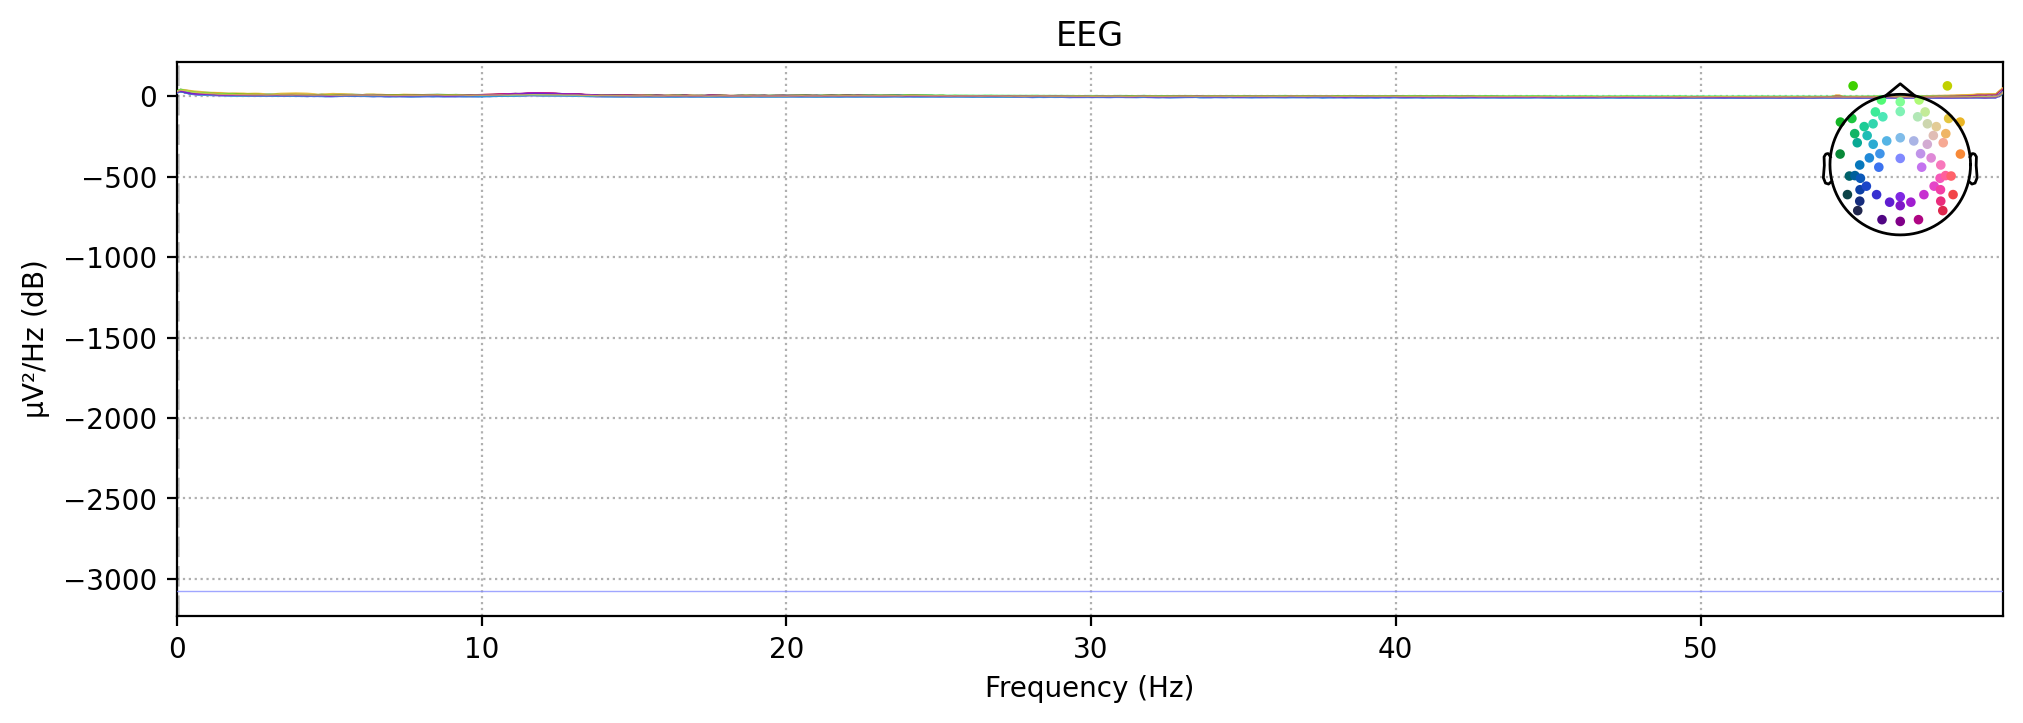

Channels marked as bad:
none


In [4]:
# Resample
raw_ec.load_data()
raw_ec.pick_types(eeg=True)
raw_ec.resample(250, npad="auto")

raw_ec.plot(n_channels=64, duration=20)
raw_ec.compute_psd(fmax=60).plot()

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1651 samples (6.604 s)

Effective window size : 8.192 (s)


/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/3145563115.py:7: UserWarning: Zero value in spectrum for channel VREF
  raw_ec.compute_psd(fmax=80).plot()
/var/folders/ff/_h9thh4n2qddnyvt9m5ncxp40000gn/T/ipykernel_66138/3145563115.py:7: UserWarning: Infinite value in PSD for channel VREF.
These channels might be dead.
  raw_ec.compute_psd(fmax=80).plot()


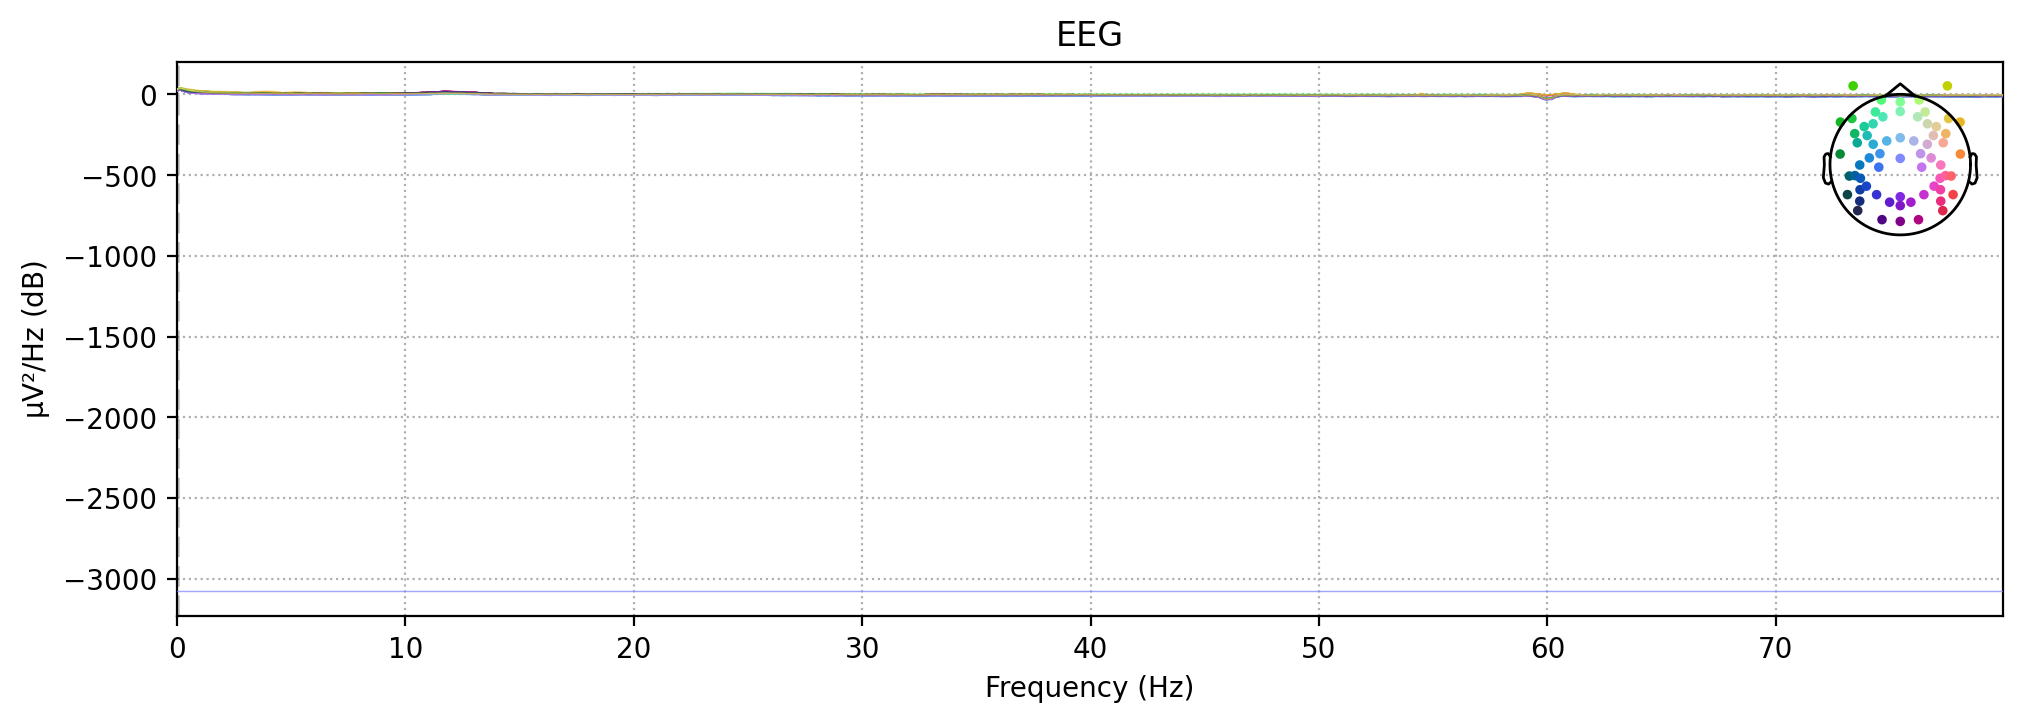

Channels marked as bad:
none


In [5]:
# =========================# NOTCH FILTER (60 Hz)


raw_ec.notch_filter(freqs=60)

raw_ec.plot(n_channels=64, duration=20)
raw_ec.compute_psd(fmax=80).plot()

In [ ]:
# HIGH-PASS FILTER (0.5 Hz)

raw_ec.filter(l_freq=0.5, h_freq=None)

raw_ec.plot(n_channels=64, duration=20)
raw_ec.compute_psd(fmax=40).plot()

EC onset (original raw time): 801.80 sec (13.36 min)
EC duration after discard: 9.85 min


<bound method BaseRaw.plot of <RawMff | signal1.bin, 68 x 590719 (590.7 s), ~306.6 MB, data loaded>>

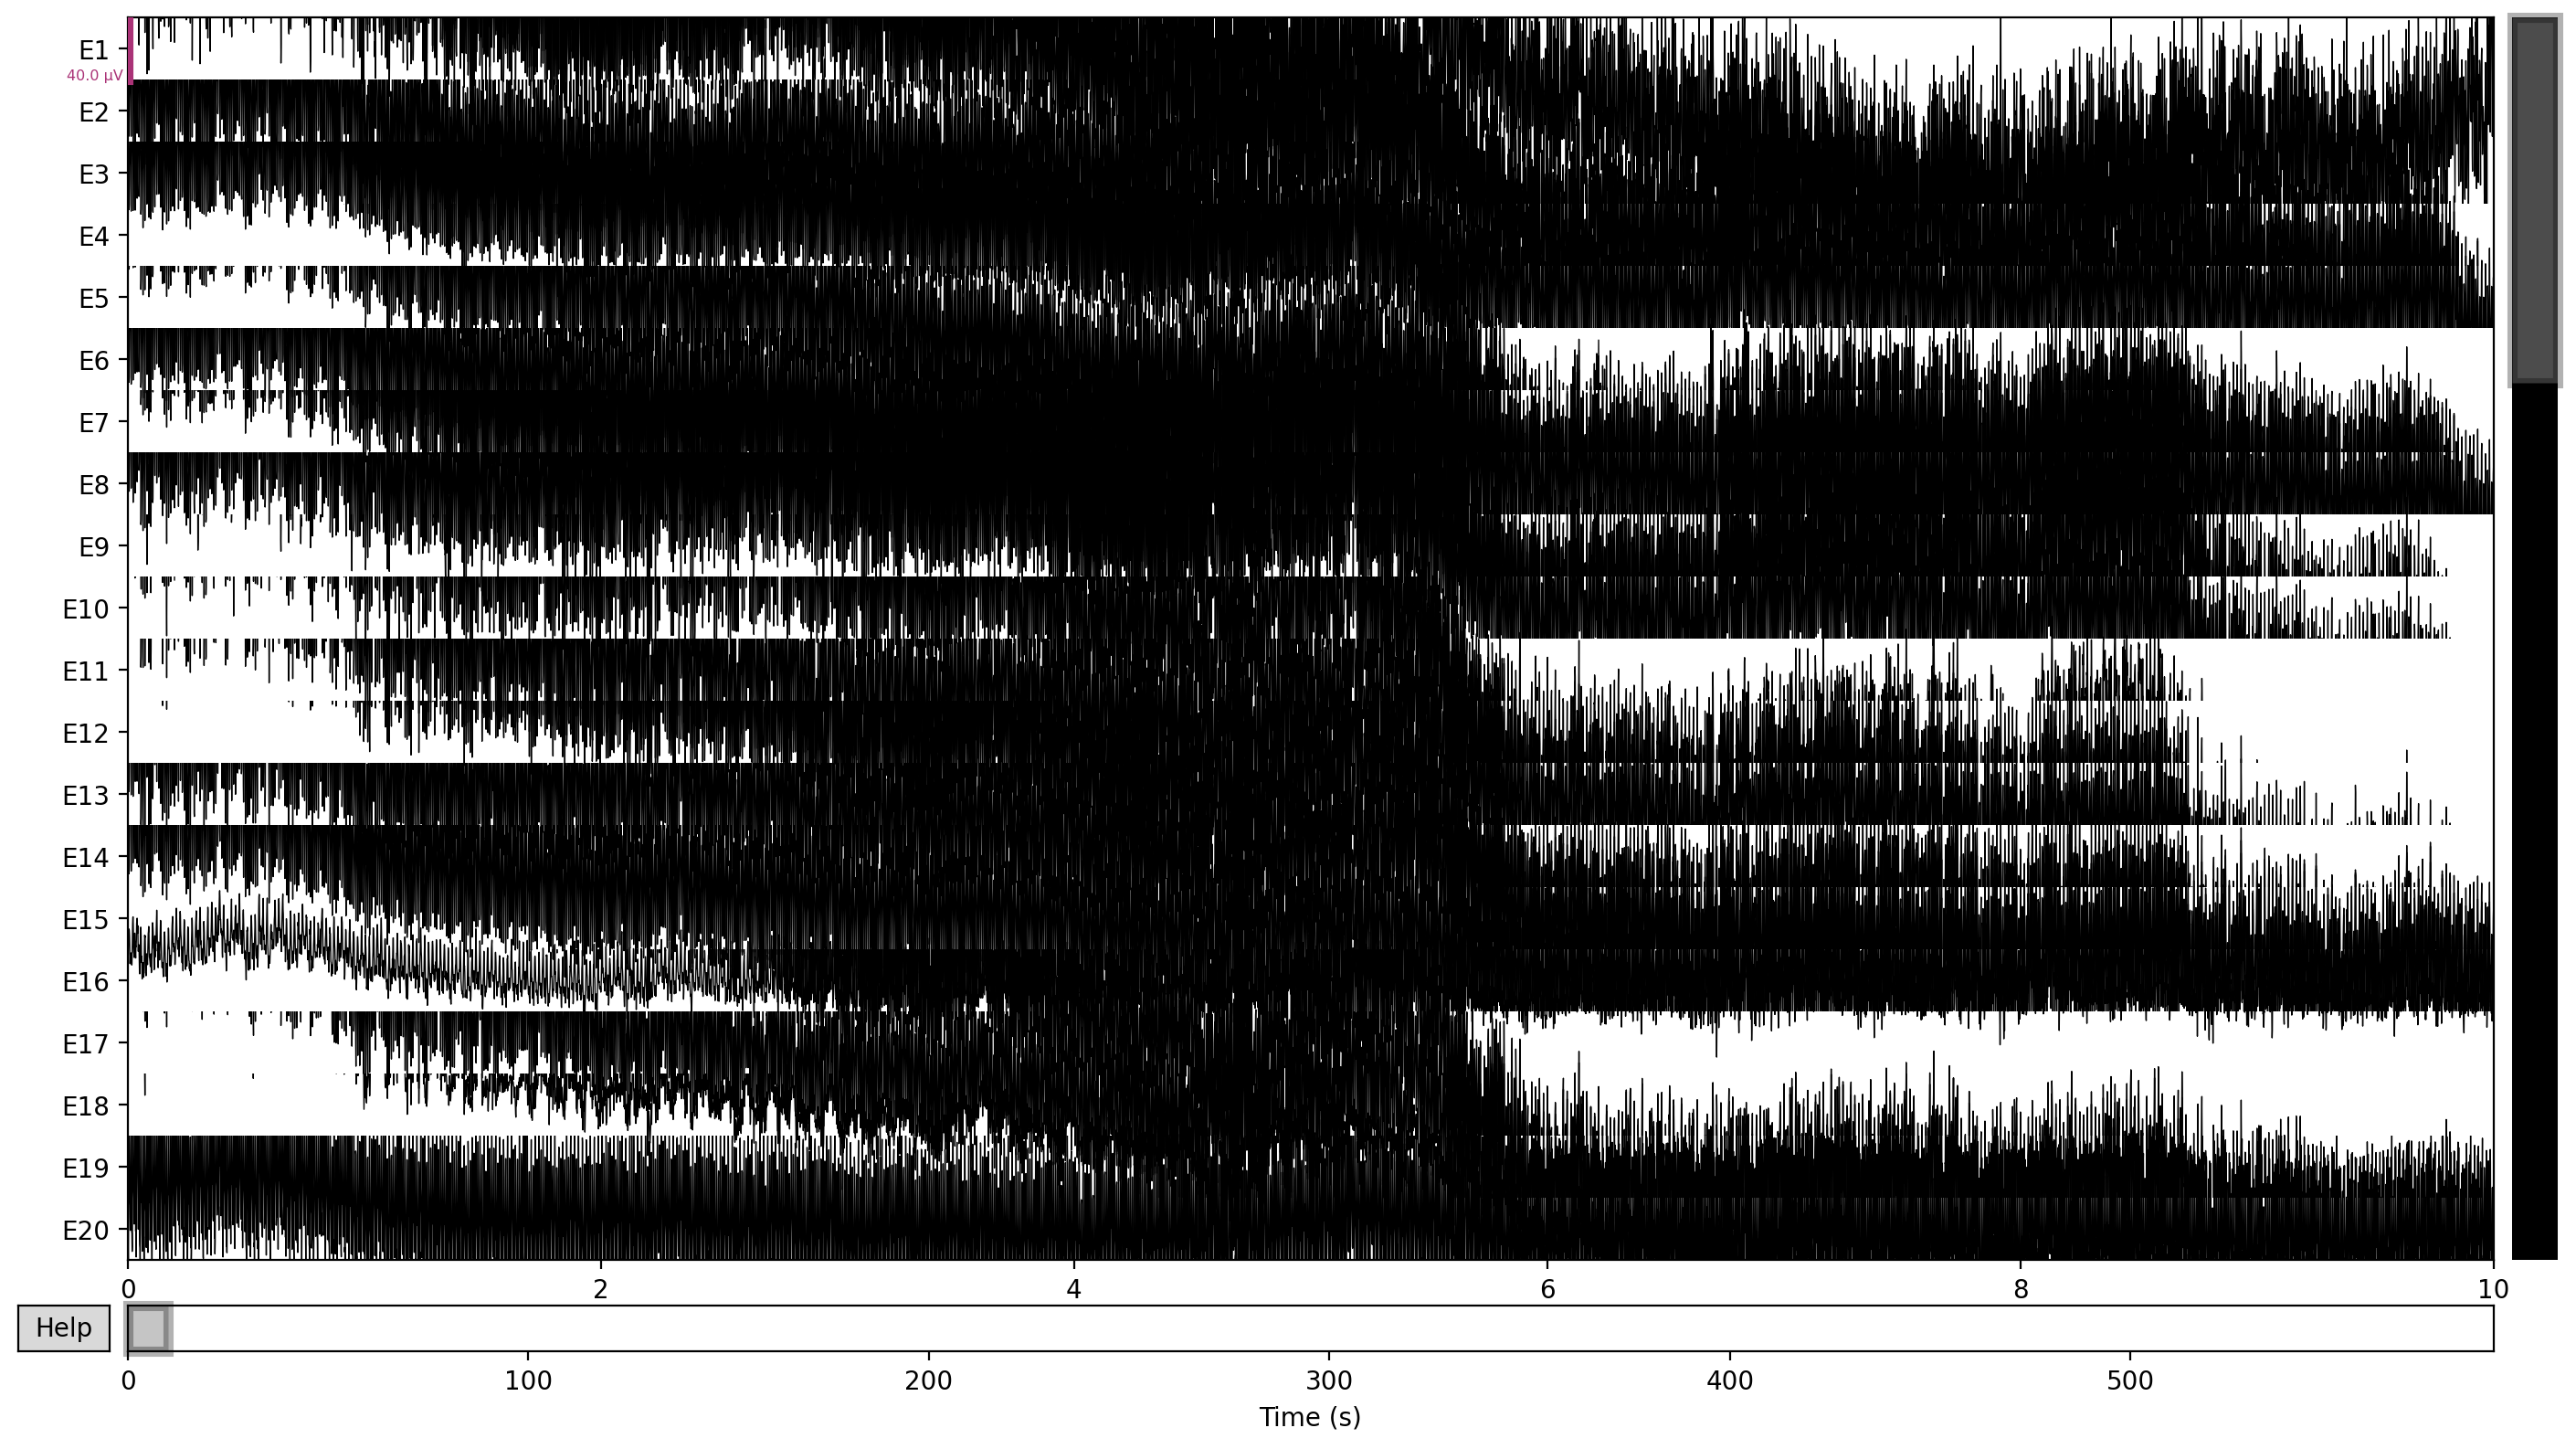

Channels marked as bad:
none


In [ ]:
# AVERAGE REFERENCE

raw_ec.set_eeg_reference("average", projection=False)

raw_ec.plot(n_channels=64, duration=20)
raw_ec.compute_psd(fmax=40).plot()